User ID                    0
Instagram visit score      0
Spending_rank(0 to 100)    0
dtype: int64
(2600, 3)
Column names in the dataset: ['User ID', 'Instagram visit score', 'Spending_rank(0 to 100)']


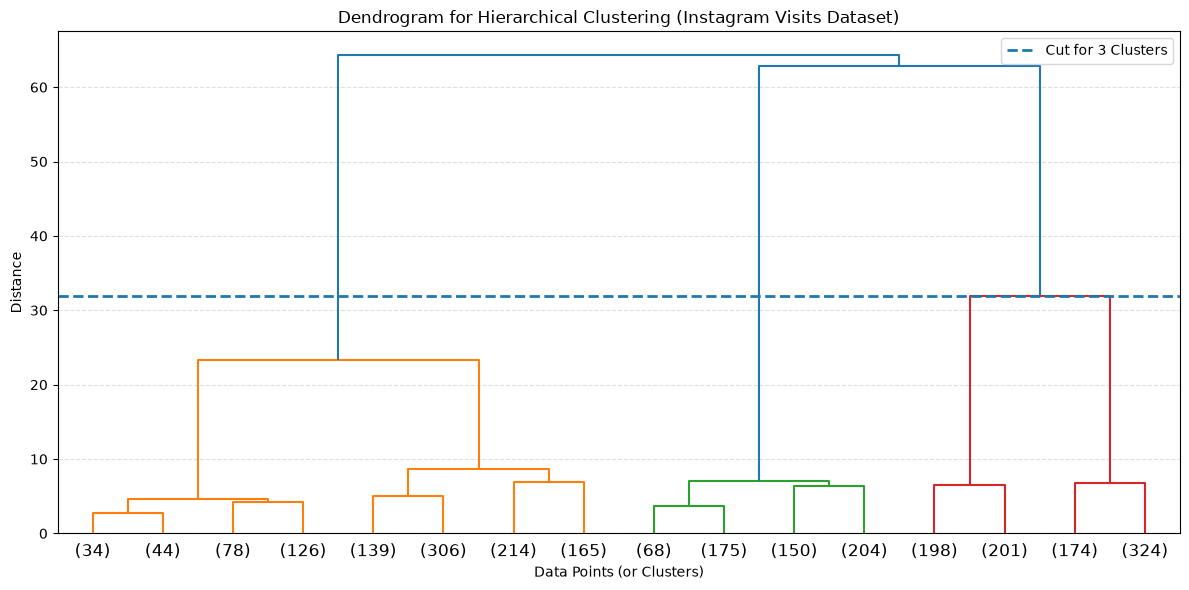

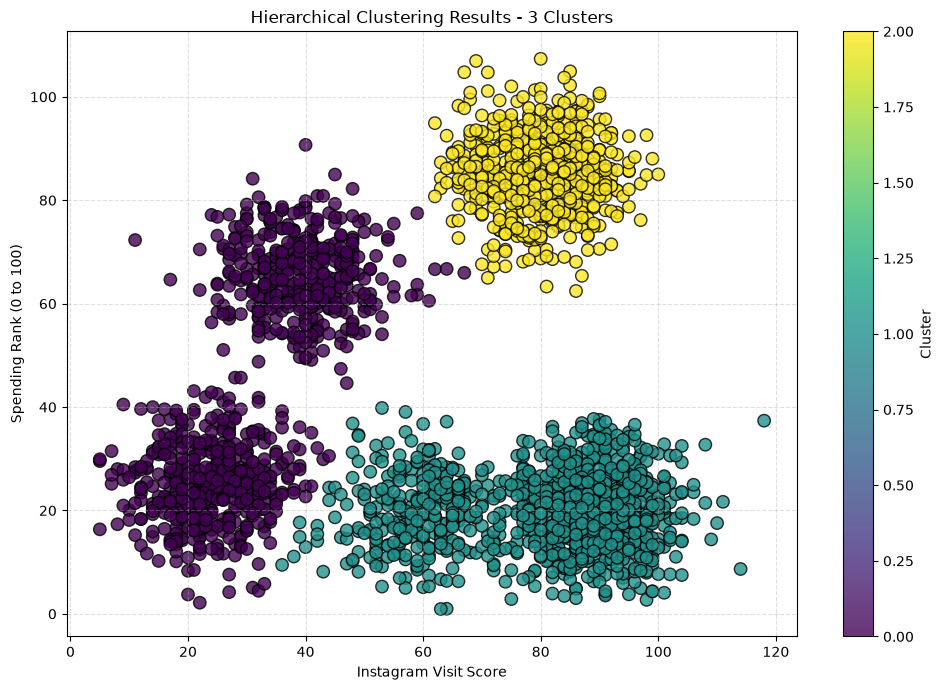

Number of points in each cluster: [ 897 1106  597]


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

# Step 1: Load the Instagram Visits dataset from CSV
data = pd.read_csv('Instagram visits clustering.csv')
df= data.isnull().sum()
print(df)
print(data.shape)

# Step 2: Inspect column names to verify dataset structure
print("Column names in the dataset:", data.columns.tolist())

# Step 3: Preprocess the data
# Drop non-numerical/identifier column (User ID)
data = data.drop('User ID', axis=1)

# Select numerical columns for clustering
numerical_columns = [
    'Instagram visit score',
    'Spending_rank(0 to 100)'
]

data = data[numerical_columns]
# Select features for clustering
X = data[
    ['Instagram visit score',
     'Spending_rank(0 to 100)']
].values

# Standardize the features to ensure equal weighting
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Compute the linkage matrix for hierarchical clustering
# Using Ward's method for linkage
linkage_matrix = linkage(
    X_scaled,
    method='ward'
)

# Step 5: Plot the dendrogram
plt.figure(figsize=(12, 6))
dendrogram(
    linkage_matrix,
    truncate_mode='level',
    p=3
)
# Last 3 merges ko dekha
# 3 clusters ke liye cut distance choose karne ke liye
# third-last merge ke neeche distance li ja rahi hai
cut_distance = linkage_matrix[-3, 2]
plt.axhline(
    y=cut_distance,
    linestyle='--',
    linewidth=2,
    label='Cut for 3 Clusters'
)
plt.title(
    'Dendrogram for Hierarchical Clustering (Instagram Visits Dataset)'
)
plt.xlabel('Data Points (or Clusters)')
plt.ylabel('Distance')
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)
plt.legend()
plt.tight_layout()
plt.show()
plt.close()

# Step 6: Perform agglomerative clustering
# Choose 3 clusters based on the dendrogram
model = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

labels = model.fit_predict(X_scaled)


# Step 7: Visualize the clusters
# using Instagram visit score and Spending_rank

plt.figure(figsize=(10, 7))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    cmap='viridis',
    s=80,
    alpha=0.8,
    edgecolors='black'
)

plt.title(
    'Hierarchical Clustering Results - 3 Clusters'
)

plt.xlabel('Instagram Visit Score')
plt.ylabel('Spending Rank (0 to 100)')
plt.grid(
    True,
    linestyle='--',
    alpha=0.4
)

# Show cluster color information
plt.colorbar(label='Cluster')
plt.tight_layout()
# IMPORTANT: Display diagram in Jupyter Notebook
plt.show()
plt.close()
# Step 8: Print number of points in each cluster
print(
    "Number of points in each cluster:",
    np.bincount(labels)
)